In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from config_mounir import NearOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite, performance_report

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

(Passage à **3 modalités**, **Near OOD**)

Le but ici est de passer à 3 modalités. Comme Kinetics n'est pas disponible et que HMDB n'a pas l'audio, on est obligé de faire du Near OOD. Et comme il n'a pas été procuré de modèle entraîné sur HAC en Near OOD, on est obligé de faire les expériences sur EPIC.

Même principe que far ood mais on a une dimension en plus (React(audio))

On charge les fichiers conf sur EPIC en Near OOD, mais provenant de différents splits. Le split "test" (de même que "train" qu'on utilisera pas) contient les classes 0 à 3 pour l'ID, et le split "eval" contient les classes de 4 à 7 pour l'OOD. 

In [3]:
root_dir = "/data/maouche/MultiOOD/EPIC-rgb-flow/saved_files/"
modalities = ['video', 'flow', "audio"] #

## Création des datasets

Données ID

In [4]:
template_sans_react =  "id_EPIC_near_ood_conf_vfa_baseline_best_test.npy"
template_react_tout = "id_EPIC_near_ood_conf_vfa_baseline_best_react_test.npy"
template_par_modalite = "id_EPIC_near_ood_conf_vfa_baseline_best_react_{}_test.npy"

# Sans react
conf_sans_react = np.load(root_dir+template_sans_react)
conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

# React sur tout
conf_react_tout = np.load(root_dir+template_react_tout)
conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


# React par modalité
conf_une_modalite = []
for modality in modalities:
    x = np.load(root_dir+template_par_modalite.format(modality))
    x = x.reshape(x.shape[0], 1)
    conf_une_modalite.append(x)
conf_une_modalite = np.hstack(conf_une_modalite)

dataset_id = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)

Données OOD

In [36]:
template_sans_react =  "id_EPIC_near_ood_conf_vfa_baseline_best_eval.npy"
template_react_tout = "id_EPIC_near_ood_conf_vfa_baseline_best_react_eval.npy"
template_par_modalite = "id_EPIC_near_ood_conf_vfa_baseline_best_react_{}_eval.npy"

# Sans react
conf_sans_react = np.load(root_dir+template_sans_react)
conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

# React sur tout
conf_react_tout = np.load(root_dir+template_react_tout)
conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


# React par modalité
conf_une_modalite = []
for modality in modalities:
    x = np.load(root_dir+template_par_modalite.format(modality))
    x = x.reshape(x.shape[0], 1)
    conf_une_modalite.append(x)
conf_une_modalite = np.hstack(conf_une_modalite)


dataset_ood = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)

In [41]:
X = np.vstack([dataset_id, dataset_ood])

Création des labels

In [ ]:
# inutile mais bon pour visualisation
template_label_id =  "id_EPIC_near_ood_label_vfa_baseline_best_test.npy"
labels_id = np.load(root_dir+template_label_id)

template_label_ood =  "id_EPIC_near_ood_label_vfa_baseline_best_eval.npy"
labels_ood = np.load(root_dir+template_label_ood)
print(np.unique(labels_id, return_counts=True), len(labels_id))
print(np.unique(labels_ood, return_counts=True), len(labels_ood))


(array([0, 1, 2, 3]), array([174, 211,  84,  67])) 536
(array([4, 5, 6, 7]), array([1053,  139,   54,   74])) 1320


In [51]:
y_id = np.zeros(dataset_id.shape[0])
y_id = y_id.reshape(y_id.shape[0], 1)

y_ood = np.ones(dataset_ood.shape[0])
y_ood = y_ood.reshape(y_ood.shape[0], 1)

Y = np.vstack([y_id, y_ood])

In [43]:
X.shape, Y.shape

((1856, 5), (1856, 1))

## Création des dataloaders

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
with open("data_vfa.pkl", 'wb') as f:
    pickle.dump(data, f)

# Chargement des données

In [3]:
with open('data_vfa.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


In [5]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([107, 265]))


# Modèle 1 Couche

In [8]:
input_dim = 5 # react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

## Entrainement

cuda
accuracy train:  0.588027685880661


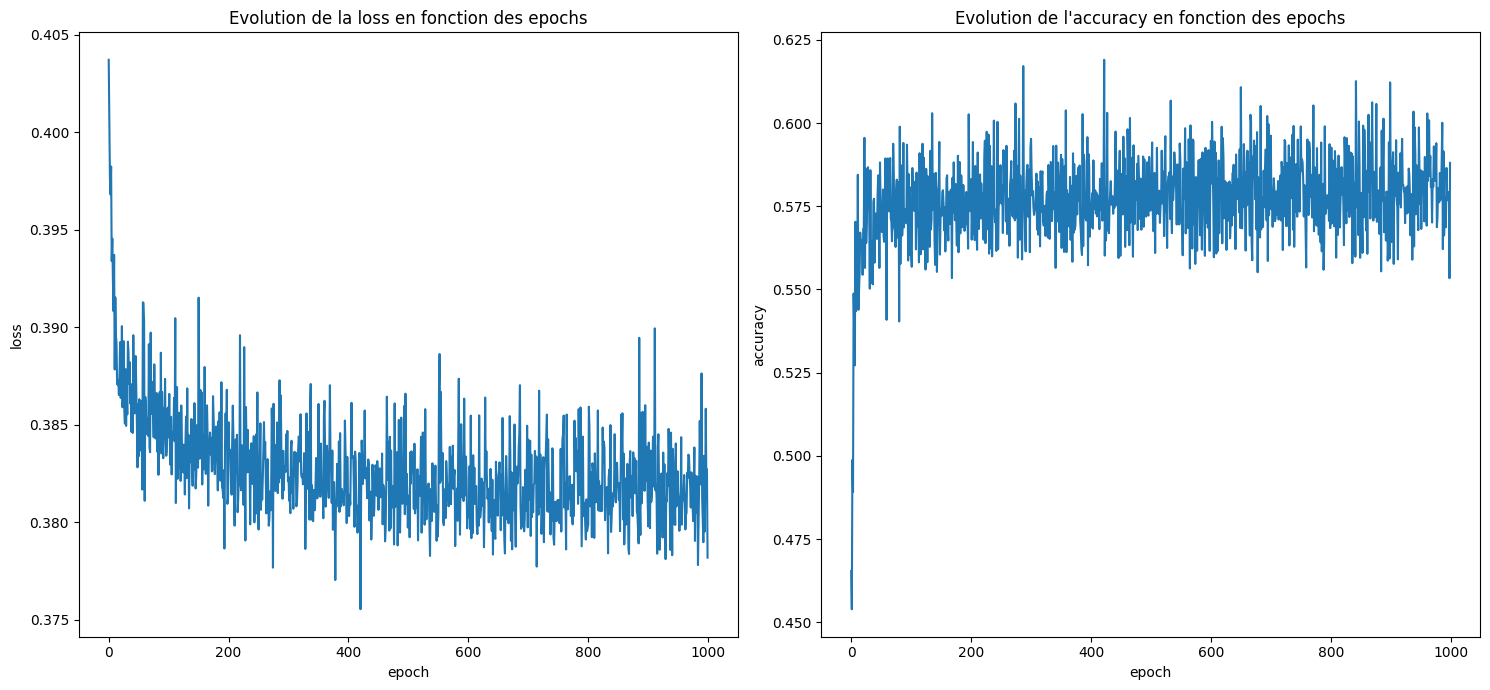

In [14]:
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=1.5
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 1000
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
#torch.save(model.state_dict(), "model_vfa2.pth")

In [68]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-0.3192, -0.0850, -0.2925, -0.6136, -0.7615]])
bias
tensor([1.6822])


In [8]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_vfa.pth"))

<All keys matched successfully>

In [7]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)
poids = dict(model.named_parameters())["weight"].detach().numpy().squeeze().round(4)

weight
tensor([[-3.3260,  5.2983, -3.6737,  1.6196, -2.8017]])
bias
tensor([2.5156])


## Tests

Accuracy test:  0.7124
Séparabilité:


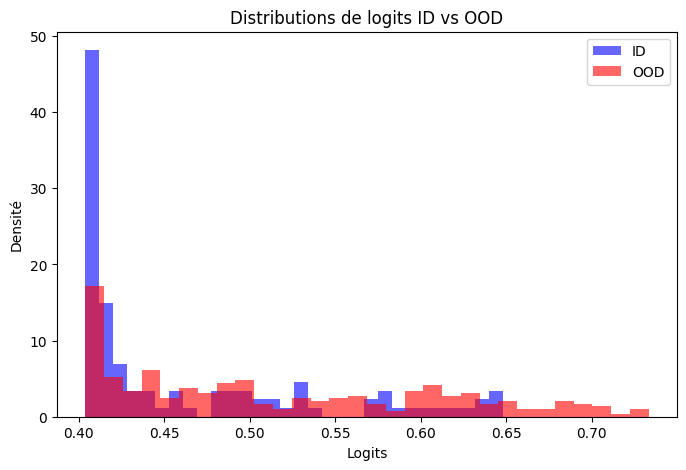

AUC ROC: 0.6993
FPR@TPR95: 0.7477

Correlation ID :  0.8407092510261388
Correlation OOD :  0.7555988621321205


,config,tout,video,flow,audio
0,poids_vfa,-0.0850,-0.2925,-0.6136,-0.7615
1,perturbation_vfa_id,0.0246,0.0100,0.0053,0.0078
2,perturbation_vfa_ood,0.0134,0.0059,0.0012,0.0058


In [9]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("vfa"))

# Modèle 2 Couches

cuda
accuracy train:  0.5486567964156469


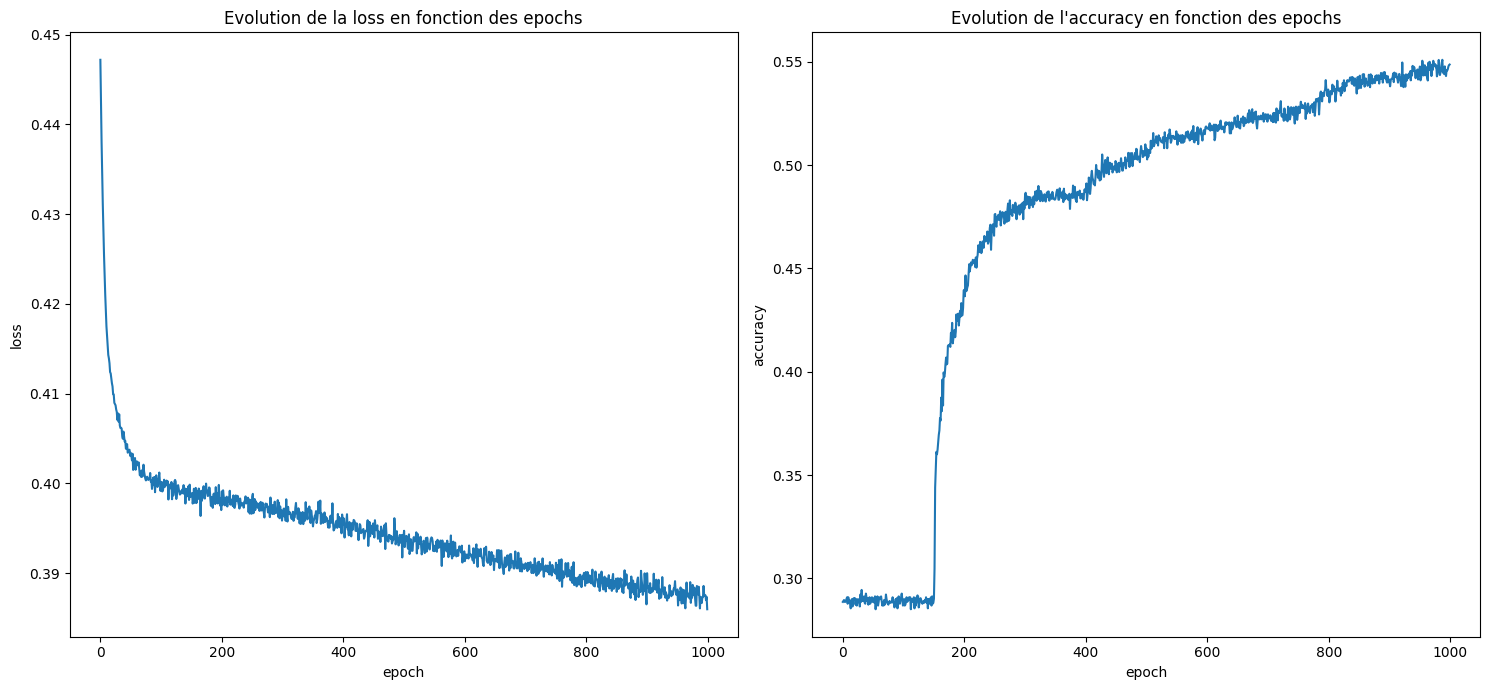

cuda
accuracy train:  0.6066337724526724


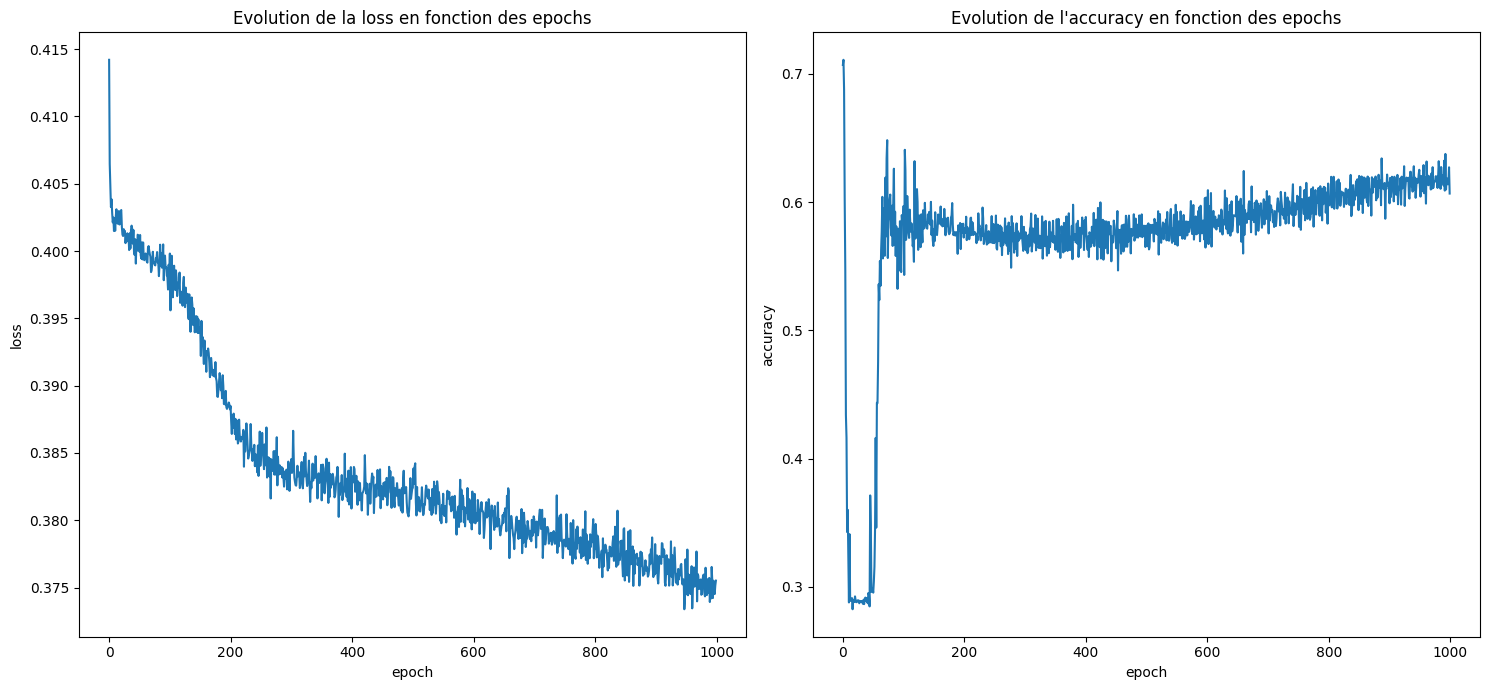

cuda
accuracy train:  0.6294202307860056


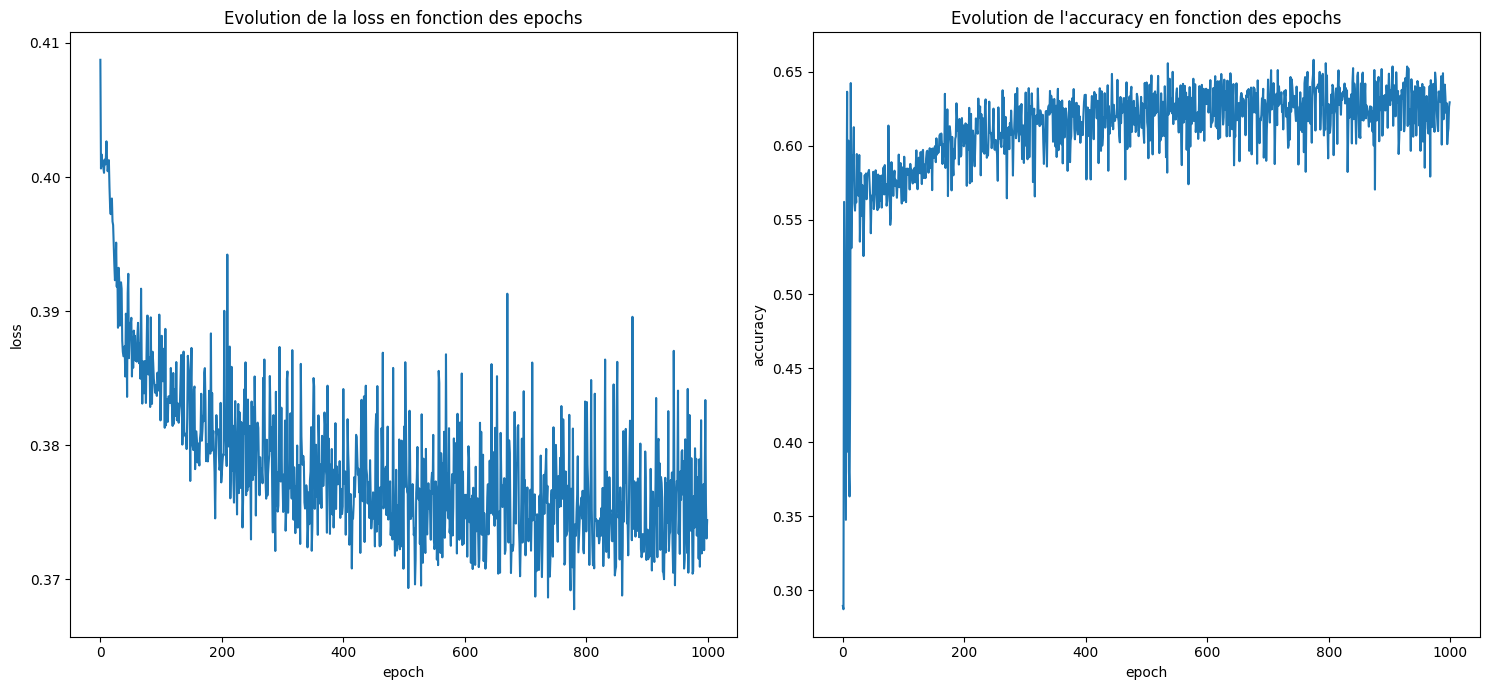

cuda
accuracy train:  0.48790433009465534


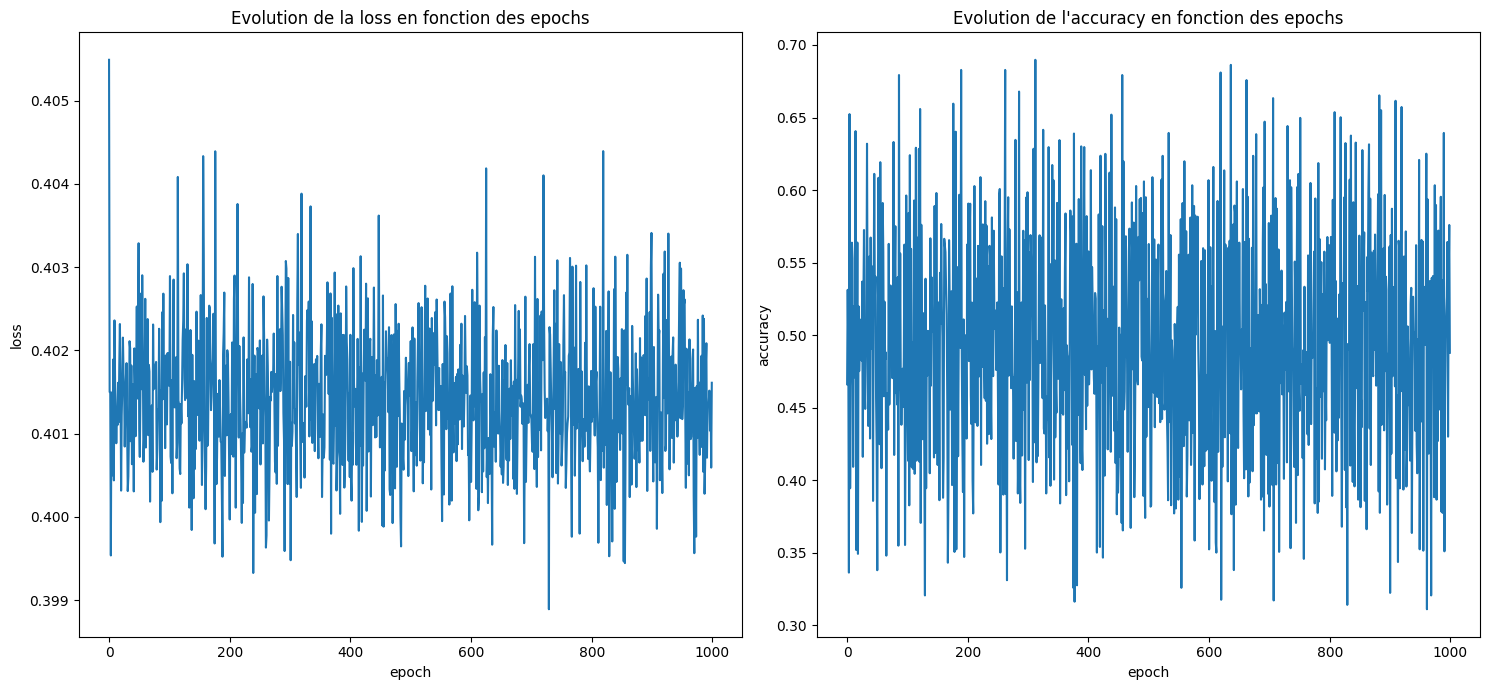

In [20]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

cuda
accuracy train:  0.5664747804403305


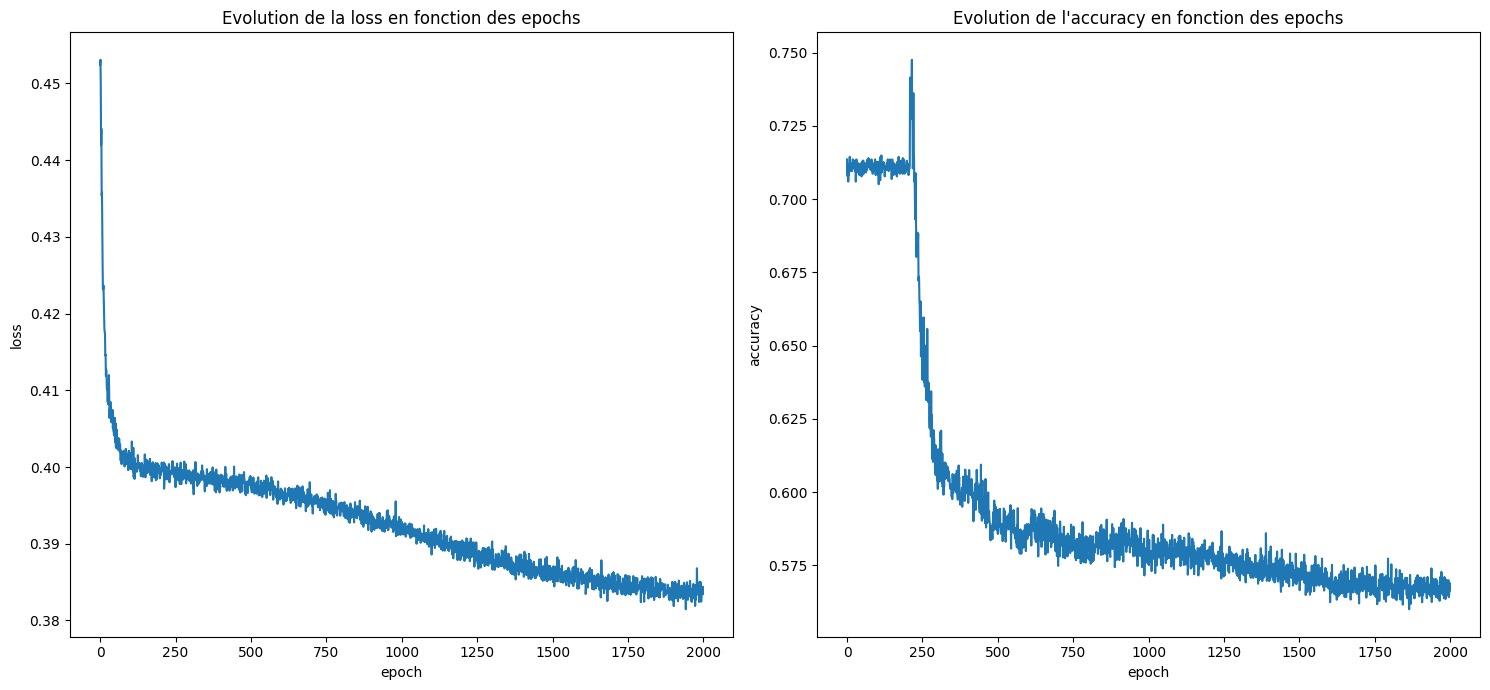

cuda
accuracy train:  0.6650561938683192


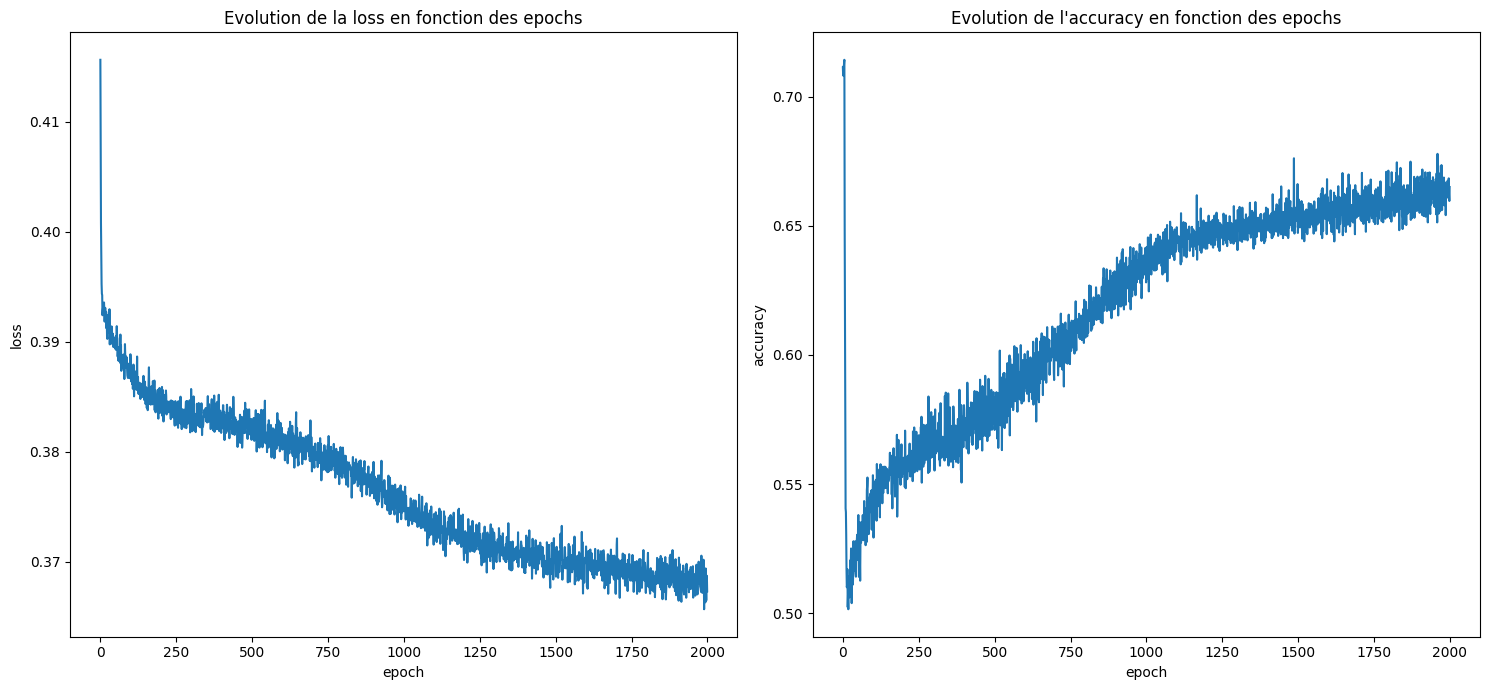

cuda
accuracy train:  0.48091420034567517


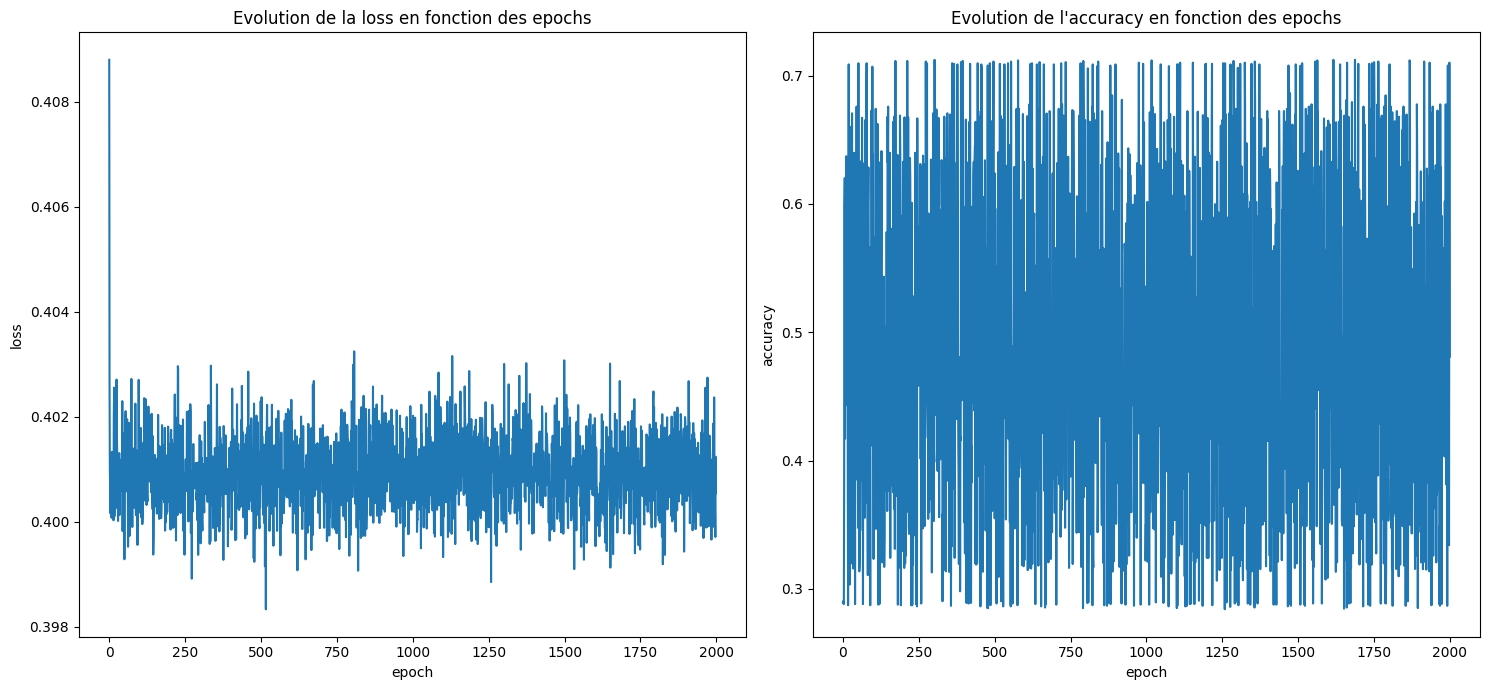

In [22]:
models = {}
nb_epochs = 2000
for lr in [1e-2, 0.5*1e-1, 0.5]:
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [23]:
model = models[0.5*1e-1]
torch.save(model.state_dict(), "model_vfa_2c.pth")

In [10]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_vfa_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.7124
Séparabilité:


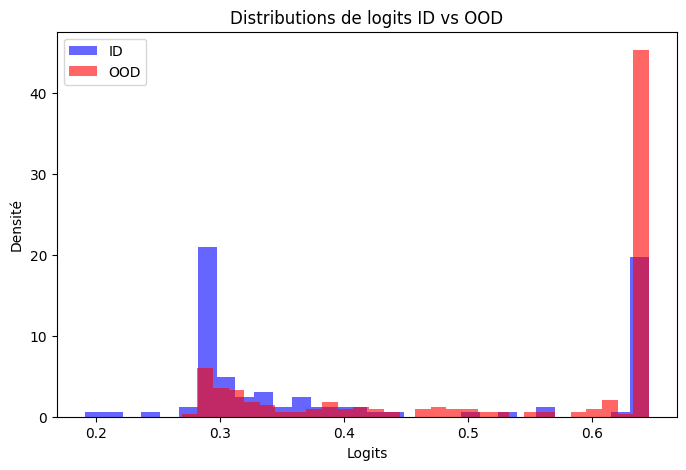

AUC ROC: 0.7027
FPR@TPR95: 0.729



In [27]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("vfa"), correlations=False)